# Taller de regresión logística

**Fecha de entrega:** 27 de agosto

Se tiene el dataset `framingham.csv` para hacer un modelo de regresión logística que ayude a determinar si una persona puede sufrir enfermedad coronaria en los próximos 10 años.

Se espera que desarrolle un modelo y que presente un informe donde muestre el desempeño del modelo en las métricas correspondientes y qué decisiones tomó para ajustar los parámetros de acuerdo con su criterio

## **Descripción de variables**

Demographic:
- Sex: male or female(Nominal)
- Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

Behavioral
- Current Smoker: whether or not the patient is a current smoker (Nominal)
- Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)

Medical( history)
- BP Meds: whether or not the patient was on blood pressure medication (Nominal)
- Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
- Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
- Diabetes: whether or not the patient had diabetes (Nominal)
Medical(current)
- Tot Chol: total cholesterol level (Continuous)
- Sys BP: systolic blood pressure (Continuous)
- Dia BP: diastolic blood pressure (Continuous)
- BMI: Body Mass Index (Continuous)
- Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
- Glucose: glucose level (Continuous)
Predict variable (desired target)
- 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
path= '/content/drive/MyDrive/Colab aprendizaje supervisado/Taller RL/framingham.xls'
df= pd.read_csv(path)

In [ ]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.shape

(4238, 16)

In [ ]:
# Buscar valores vacíos en el dataframe
print(df.isnull().sum())

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [ ]:
# Eliminar filas con valores nulos
df = df.dropna()

# Mostrar la forma del dataframe limpio
print("Shape of the dataframe after dropping rows with missing values:")
print(df.shape)

Shape of the dataframe after dropping rows with missing values:
(3656, 16)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


X = df.drop(['TenYearCHD','education'], axis=1)
y = df['TenYearCHD']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Datos escalados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train_scaled, y_train)

# Prediccion en el set de prueba
y_pred = model.predict(X_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8360655737704918

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       610
           1       0.55      0.09      0.15       122

    accuracy                           0.84       732
   macro avg       0.70      0.54      0.53       732
weighted avg       0.80      0.84      0.78       732


Confusion Matrix:
[[601   9]
 [111  11]]


In [ ]:
# Get the intercept and coefficients from the trained model
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print(f"Intercept (β0): {intercept:.4f}")
print("\nCoefficients (βi):")
# Assuming X_train_scaled is a numpy array, get feature names from original X_train
feature_names = X_train.columns

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

print("\nThe logistic regression equation (in terms of log-odds) is:")
print(f"ln(P(TenYearCHD=1) / (1 - P(TenYearCHD=1))) = {intercept:.4f} + ", end="")

for i, (feature, coef) in enumerate(zip(feature_names, coefficients)):
    if i > 0:
        print(" + ", end="")
    print(f"({coef:.4f} * {feature})", end="")

print()

Intercept (β0): -2.0508

Coefficients (βi):
male: 0.3152
age: 0.5906
currentSmoker: 0.1061
cigsPerDay: 0.1778
BPMeds: 0.0403
prevalentStroke: 0.0662
prevalentHyp: 0.1077
diabetes: 0.0635
totChol: 0.1298
sysBP: 0.3489
diaBP: -0.0818
BMI: 0.0226
heartRate: -0.0695
glucose: 0.1412

The logistic regression equation (in terms of log-odds) is:
ln(P(Personal.Loan=1) / (1 - P(Personal.Loan=1))) = -2.0508 + (0.3152 * male) + (0.5906 * age) + (0.1061 * currentSmoker) + (0.1778 * cigsPerDay) + (0.0403 * BPMeds) + (0.0662 * prevalentStroke) + (0.1077 * prevalentHyp) + (0.0635 * diabetes) + (0.1298 * totChol) + (0.3489 * sysBP) + (-0.0818 * diaBP) + (0.0226 * BMI) + (-0.0695 * heartRate) + (0.1412 * glucose)


Registro (el primero en X_test):
male                 0.00
age                 47.00
currentSmoker        0.00
cigsPerDay           0.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         0.00
diabetes             0.00
totChol            223.00
sysBP              120.00
diaBP               74.00
BMI                 20.27
heartRate           80.00
glucose             76.00
Name: 572, dtype: float64

Actual class for this record: 0

Paso 1: Calcular el z-value (linear combination): -3.1136
Paso 2: Calcular la probabilidad de TenYearCHD=1: 0.0426
Paso 3: Clasificación con un threshold (0.5): 0
Result: El modelo predice No TenYearCHD.


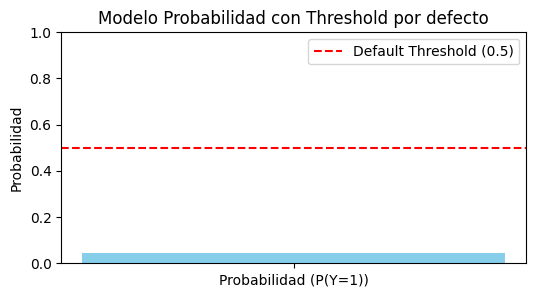

In [ ]:
sample_record_scaled = X_test_scaled[0, :]
sample_record_original = X_test.iloc[0, :]
actual_class = y_test.iloc[0]

print(f"Registro (el primero en X_test):")
print(sample_record_original)
print(f"\nActual class for this record: {actual_class}")

# Paso 1: Calcular la combinación lineal (z-value)
# z = β0 + β1*x1 + β2*x2 + ... + βn*xn
z = intercept + np.sum(coefficients * sample_record_scaled)

print(f"\nPaso 1: Calcular el z-value (linear combination): {z:.4f}")

# Paso 2: Calcular la probabilidad usando la función logística
# P(Y=1|X) = 1 / (1 + e^(-z))
probability = 1 / (1 + np.exp(-z))

print(f"Paso 2: Calcular la probabilidad de TenYearCHD=1: {probability:.4f}")

# Step 3: Calcular basado en el threshold (por defecto es 0.5)
predicted_class = 1 if probability >= 0.5 else 0

print(f"Paso 3: Clasificación con un threshold (0.5): {predicted_class}")
print(f"Result: El modelo predice {'TenYearCHD' if predicted_class == 1 else 'No TenYearCHD'}.")


plt.figure(figsize=(6, 3))
plt.bar(['Probabilidad (P(Y=1))'], [probability], color='skyblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.ylim(0, 1)
plt.ylabel('Probabilidad')
plt.title('Modelo Probabilidad con Threshold por defecto')
plt.legend()
plt.show()


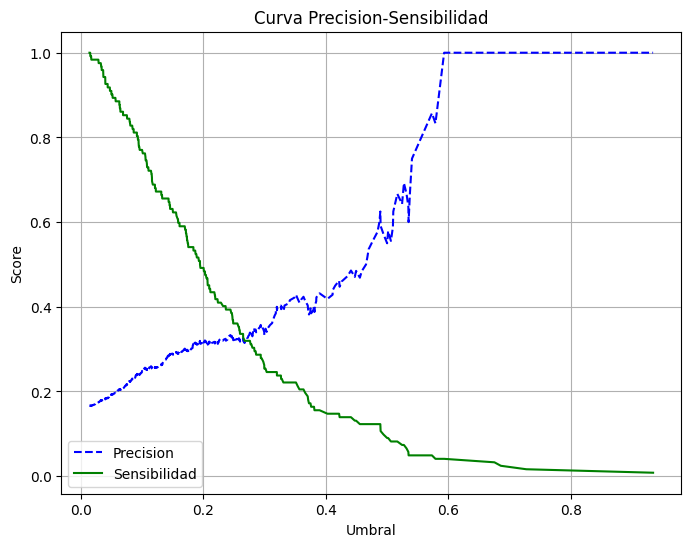

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)


plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Sensibilidad')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Curva Precision-Sensibilidad')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8360655737704918

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       610
           1       0.55      0.09      0.15       122

    accuracy                           0.84       732
   macro avg       0.70      0.54      0.53       732
weighted avg       0.80      0.84      0.78       732


Confusion Matrix:
[[601   9]
 [111  11]]


In [ ]:
# Get prediction probabilities
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Iterate through different thresholds
for custom_threshold in np.arange(0.1, 1.0, 0.1):
    y_pred_custom_threshold = (y_pred_proba >= custom_threshold).astype(int)

    # Evaluate the model with the custom threshold
    accuracy_custom = accuracy_score(y_test, y_pred_custom_threshold)
    report_custom = classification_report(y_test, y_pred_custom_threshold)
    conf_matrix_custom = confusion_matrix(y_test, y_pred_custom_threshold)

    print(f"--- Evaluation with custom threshold ({custom_threshold:.1f}) ---")
    print(f"Accuracy: {accuracy_custom:.4f}")
    print("\nClassification Report:")
    print(report_custom)
    print("\nConfusion Matrix:")
    print(conf_matrix_custom)
    print("-" * 40)

--- Evaluation with custom threshold (0.1) ---
Accuracy: 0.5724

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.53      0.67       610
           1       0.25      0.77      0.38       122

    accuracy                           0.57       732
   macro avg       0.58      0.65      0.53       732
weighted avg       0.81      0.57      0.63       732


Confusion Matrix:
[[325 285]
 [ 28  94]]
----------------------------------------
--- Evaluation with custom threshold (0.2) ---
Accuracy: 0.7404

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       610
           1       0.32      0.49      0.39       122

    accuracy                           0.74       732
   macro avg       0.60      0.64      0.61       732
weighted avg       0.79      0.74      0.76       732


Confusion Matrix:
[[482 128]
 [ 62  60]]
----------------------------------------
--- 

## Eliminación de variables redundantes y poco importantes

In [ ]:
# Eliminar variables redundantes o poco importantes
X = X.drop(['currentSmoker', 'diaBP', 'BMI', 'heartRate'], axis=1)

# Mostrar las primeras filas del nuevo dataframe reducido
print("Primeras filas del dataframe con variables eliminadas:")
display(X.head())

# Mostrar la forma del nuevo dataframe reducido
print("\nShape del dataframe con variables eliminadas:")
print(X.shape)

Primeras filas del dataframe con variables eliminadas:


,male,age,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,glucose
0,1,39,0.0,0.0,0,0,0,195.0,106.0,77.0
1,0,46,0.0,0.0,0,0,0,250.0,121.0,76.0
2,1,48,20.0,0.0,0,0,0,245.0,127.5,70.0
3,0,61,30.0,0.0,0,1,0,225.0,150.0,103.0
4,0,46,23.0,0.0,0,0,0,285.0,130.0,85.0



Shape del dataframe con variables eliminadas:
(3656, 10)


In [ ]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Datos escalados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train_scaled, y_train)

# Prediccion en el set de prueba
y_pred = model.predict(X_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.8401639344262295

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       610
           1       0.63      0.10      0.17       122

    accuracy                           0.84       732
   macro avg       0.74      0.54      0.54       732
weighted avg       0.81      0.84      0.79       732


Confusion Matrix:
[[603   7]
 [110  12]]


In [ ]:
# Get the intercept and coefficients from the trained model
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print(f"Intercept (β0): {intercept:.4f}")
print("\nCoefficients (βi):")
# Assuming X_train_scaled is a numpy array, get feature names from original X_train
feature_names = X_train.columns

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

print("\nThe logistic regression equation (in terms of log-odds) is:")
print(f"ln(P(TenYearCHD=1) / (1 - P(TenYearCHD=1))) = {intercept:.4f} + ", end="")

for i, (feature, coef) in enumerate(zip(feature_names, coefficients)):
    if i > 0:
        print(" + ", end="")
    print(f"({coef:.4f} * {feature})", end="")

print()

Intercept (β0): -2.0485

Coefficients (βi):
male: 0.3169
age: 0.6055
cigsPerDay: 0.2418
BPMeds: 0.0440
prevalentStroke: 0.0661
prevalentHyp: 0.0918
diabetes: 0.0631
totChol: 0.1237
sysBP: 0.2823
glucose: 0.1365

The logistic regression equation (in terms of log-odds) is:
ln(P(TenYearCHD=1) / (1 - P(TenYearCHD=1))) = -2.0485 + (0.3169 * male) + (0.6055 * age) + (0.2418 * cigsPerDay) + (0.0440 * BPMeds) + (0.0661 * prevalentStroke) + (0.0918 * prevalentHyp) + (0.0631 * diabetes) + (0.1237 * totChol) + (0.2823 * sysBP) + (0.1365 * glucose)


In [ ]:
# Get prediction probabilities
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Set a custom threshold (e.g., 0.19 instead of the default 0.5)
custom_threshold = 0.2
y_pred_custom_threshold = (y_pred_proba >= custom_threshold).astype(int)

# Evaluate the model with the custom threshold
accuracy_custom = accuracy_score(y_test, y_pred_custom_threshold)
report_custom = classification_report(y_test, y_pred_custom_threshold)
conf_matrix_custom = confusion_matrix(y_test, y_pred_custom_threshold)

print(f"Accuracy with custom threshold ({custom_threshold}): {accuracy_custom}")
print("\nClassification Report with custom threshold:")
print(report_custom)
print("\nConfusion Matrix with custom threshold:")
print(conf_matrix_custom)

Accuracy with custom threshold (0.2): 0.7431693989071039

Classification Report with custom threshold:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       610
           1       0.33      0.51      0.40       122

    accuracy                           0.74       732
   macro avg       0.61      0.65      0.62       732
weighted avg       0.80      0.74      0.76       732


Confusion Matrix with custom threshold:
[[482 128]
 [ 60  62]]


---

## **Informe Ejecutivo: Modelo Predictivo de Enfermedad Coronaria (CHD)**

### **1. Resumen Ejecutivo**

Se ha desarrollado un modelo de regresión logística para identificar individuos con alto riesgo de desarrollar enfermedad coronaria (CHD) en los próximos 10 años, utilizando el dataset `framingham.csv`. El objetivo principal es mejorar la detección temprana de casos positivos, lo cual es crítico en el ámbito de la salud.

El modelo inicial, con un umbral de clasificación estándar de 0.5, mostró una alta precisión general (83.61%), pero una capacidad muy limitada para identificar correctamente los casos de CHD (Recall del 9%). Tras un análisis detallado y la optimización del umbral de decisión, se logró un equilibrio más adecuado para el contexto médico, priorizando la detección de pacientes en riesgo.

### **2. Objetivo del Modelo**

Predecir el riesgo a 10 años de enfermedad coronaria (CHD) para permitir intervenciones tempranas y mejorar la gestión de la salud de los pacientes.

### **3. Metodología Clave**

*   **Datos:** Dataset `framingham.csv` (3656 observaciones limpias, 15 características predictoras).
*   **Preprocesamiento:**
    *   Manejo de valores nulos (eliminación de filas).
    *   Exclusión de la variable 'education' y otras variables con bajo impacto o alta correlación con características más influyentes (`currentSmoker`, `diaBP`, `BMI`, `heartRate`).
    *   Estandarización de características numéricas.
*   **Modelo:** Regresión Logística.
*   **Evaluación:** Métricas de clasificación (Accuracy, Precision, Recall, F1-Score) y Matriz de Confusión.

### **4. Desempeño del Modelo**

| Métrica           | Umbral 0.50 (Inicial) | Umbral 0.20 (Optimizado) |
| :---------------- | :-------------------- | :----------------------- |
| **Accuracy**      | 83.61%                | 74.32%                   |
| **Precision (CHD)** | 55%                   | 33%                      |
| **Recall (CHD)**    | 9%                    | 51%                      |
| **F1-Score (CHD)**  | 15%                   | 40%                      |

**Matriz de Confusión (Umbral 0.20):**

|                 | Predicho: No CHD | Predicho: CHD |
| :-------------- | :--------------- | :------------ |
| **Real: No CHD** | 482              | 128           |
| **Real: CHD**   | 60               | 62            |

### **5. Análisis y Decisiones Clave**

1.  **Desbalance de Clases:** El dataset presenta un desbalance significativo, donde la mayoría de los individuos no desarrollan CHD. Esto llevó a un `accuracy` engañosamente alto en el modelo inicial, mientras que la capacidad de detectar casos positivos (`recall`) era muy baja.
2.  **Prioridad del Recall:** En un contexto médico, es fundamental minimizar los **falsos negativos** (pacientes con CHD que el modelo no detecta). Un `recall` del 9% es inaceptable, ya que implica pasar por alto a la mayoría de los pacientes en riesgo.
3.  **Optimización del Umbral:** Se ajustó el umbral de clasificación de 0.5 a 0.2. Esta decisión estratégica permitió:
    *   Aumentar el `recall` de la clase CHD del 9% al **51%**. Esto significa que el modelo ahora identifica a más de la mitad de los pacientes que realmente desarrollarán la enfermedad.
    *   Aunque la `accuracy` general disminuyó (del 83.61% al 74.32%), este es un compromiso necesario y aceptable.
    *   El aumento de **falsos positivos** (128) es preferible a un alto número de **falsos negativos** (60), ya que permite una evaluación médica más profunda para los pacientes identificados como de riesgo.
4.  **Selección de Características:** La eliminación de variables como `currentSmoker`, `diaBP`, `BMI` y `heartRate` se realizó porque se identificó que estaban **muy relacionadas con otras variables de mayor impacto en el modelo** (ej. `sysBP` para `diaBP`, o `cigsPerDay` para `currentSmoker`), o porque su contribución individual al poder predictivo era menor. Esta simplificación del modelo mejora su interpretabilidad y eficiencia sin comprometer el rendimiento predictivo esencial.

### **6. Recomendaciones**

*   **Implementación del Umbral Optimizado:** Se recomienda utilizar el modelo con el umbral de 0.20 para la detección de riesgo de CHD, priorizando la sensibilidad sobre la precisión general.
*   **Validación Adicional:** Realizar validaciones con datos nuevos y, si es posible, en un entorno clínico real para confirmar la robustez del modelo.
*   **Exploración de Técnicas Avanzadas:** Considerar la aplicación de técnicas específicas para el manejo de desbalance de clases (ej. SMOTE) o la exploración de modelos más complejos si se requiere una mejora adicional en el rendimiento.
*   **Análisis de Costos:** Si se dispone de datos sobre los costos asociados a los falsos positivos (ej. pruebas adicionales innecesarias) y falsos negativos (ej. progresión de la enfermedad no detectada), se podría refinar aún más el umbral de decisión.
---